--- Fitting Log-Normal Model (Gaussian on Log-Target) ---
Data Shape: (465, 33)
                 Generalized Linear Model Regression Results                  
Dep. Variable:              log_monto   No. Observations:                  465
Model:                            GLM   Df Residuals:                      432
Model Family:                Gaussian   Df Model:                           32
Link Function:               Identity   Scale:                          1.0149
Method:                          IRLS   Log-Likelihood:                -646.13
Date:                Sat, 21 Feb 2026   Deviance:                       438.44
Time:                        16:14:58   Pearson chi2:                     438.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.8770
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
---------

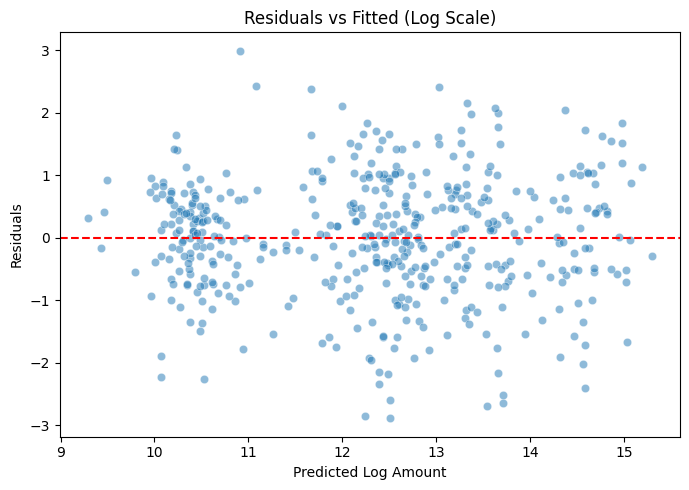

<Figure size 700x500 with 0 Axes>

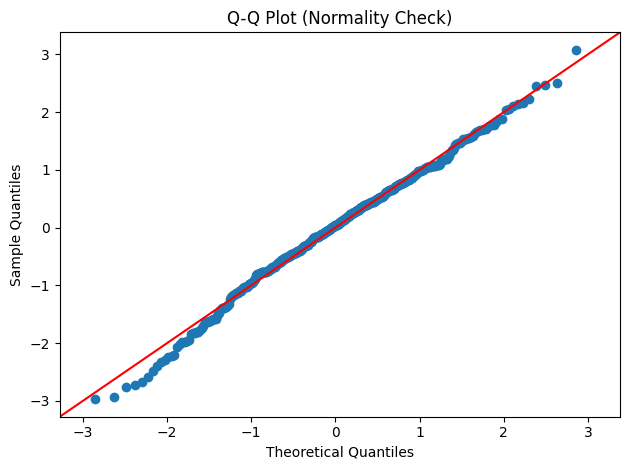

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- 1. Data Prep (Reload to ensure clean state) ---
def get_lognormal_data(filename):
    df = pd.read_csv(filename, sep=';', encoding='latin-1')
    
    # Filter Sector
    df = df[df['SECTOR'] != 'ACTIVIDADES FINANCIERAS Y DE SEGUROS'].copy()
    
    # Clean Columns
    def clean(n): return re.sub(r'[^a-zA-Z0-9_]', '_', n.strip().lower()).strip('_')
    df.columns = [clean(c) for c in df.columns]
    
    # Date -> Quarter
    date_col = [c for c in df.columns if 'fecha' in c][0]
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=True)
    df.dropna(subset=[date_col], inplace=True)
    df['quarter'] = df[date_col].dt.to_period('Q').astype(str)
    
    # TARGET TRANSFORMATION (The Key Step)
    # We log the target immediately. 
    target = 'monto_otorgado'
    df[target] = pd.to_numeric(df[target], errors='coerce')
    df = df[df[target] > 0].copy() # Log requires > 0
    df['log_monto'] = np.log(df[target])  # Y -> log(Y)
    
    # Simplify Categories
    for col in ['provincia', 'sector']:
        top = df[col].value_counts().nlargest(6).index
        df[col] = df[col].apply(lambda x: x if x in top else 'other')
        
    # Drop unused
    drop_cols = ['canton', 'subsector', 'actividad', 'subsistema', 'entidad', 'ruc', 'nombre', date_col, target]
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
    
    # Dummies
    df_final = pd.get_dummies(df, drop_first=True, dtype=int)
    df_final.columns = [clean(c) for c in df_final.columns]
    
    # Remove Duplicates & NaT
    df_final = df_final.loc[:, ~df_final.columns.duplicated()]
    return df_final.loc[:, [c for c in df_final.columns if 'nat' not in c]]

# --- 2. Fit Log-Normal GLM ---
df_log = get_lognormal_data('cfn_volumencreditocontingente_2025_enero-septiembre.csv')

# Formula uses 'log_monto' as target
target = 'log_monto'
predictors = [c for c in df_log.columns if c != target]
formula_str = f"{target} ~ {' + '.join(predictors)}"

print(f"--- Fitting Log-Normal Model (Gaussian on Log-Target) ---")
print(f"Data Shape: {df_log.shape}")

# Model: Gaussian Family with Identity Link (Standard Regression on Log Data)
# This is physically equivalent to a Log-Normal GLM
model_ln = smf.glm(
    formula=formula_str,
    data=df_log,
    family=sm.families.Gaussian(link=sm.families.links.Identity())
)

result_ln = model_ln.fit()

# Report
print(result_ln.summary())
print(f"\nAIC: {result_ln.aic:.2f}")

# --- 3. Robust Diagnostics ---
# Since we are now in "Gaussian" land (on log data), residuals should be VERY Normal.
resid = result_ln.resid_deviance
fitted = result_ln.mu

# ---- Plot 1: Residuals vs Fitted ----
plt.figure(figsize=(7, 5))
sns.scatterplot(x=fitted, y=resid, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.title('Residuals vs Fitted (Log Scale)')
plt.xlabel('Predicted Log Amount')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

# ---- Plot 2: Q-Q Plot (Normality Check) ----
plt.figure(figsize=(7, 5))
sm.qqplot(resid, line='45', fit=True)
plt.title('Q-Q Plot (Normality Check)')
plt.tight_layout()
plt.show()

<>:55: SyntaxWarning: invalid escape sequence '\s'
<>:55: SyntaxWarning: invalid escape sequence '\s'
/var/folders/3c/z87p2q816b55gkkf_05bzyhr0000gn/T/ipykernel_6848/491321799.py:55: SyntaxWarning: invalid escape sequence '\s'
  axes[1, 0].set_ylabel('$\sqrt{|Standardized Residuals|}$')
/Users/equina/Documents/Generalized_Linear_Model_CFN/.venv/lib/python3.13/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


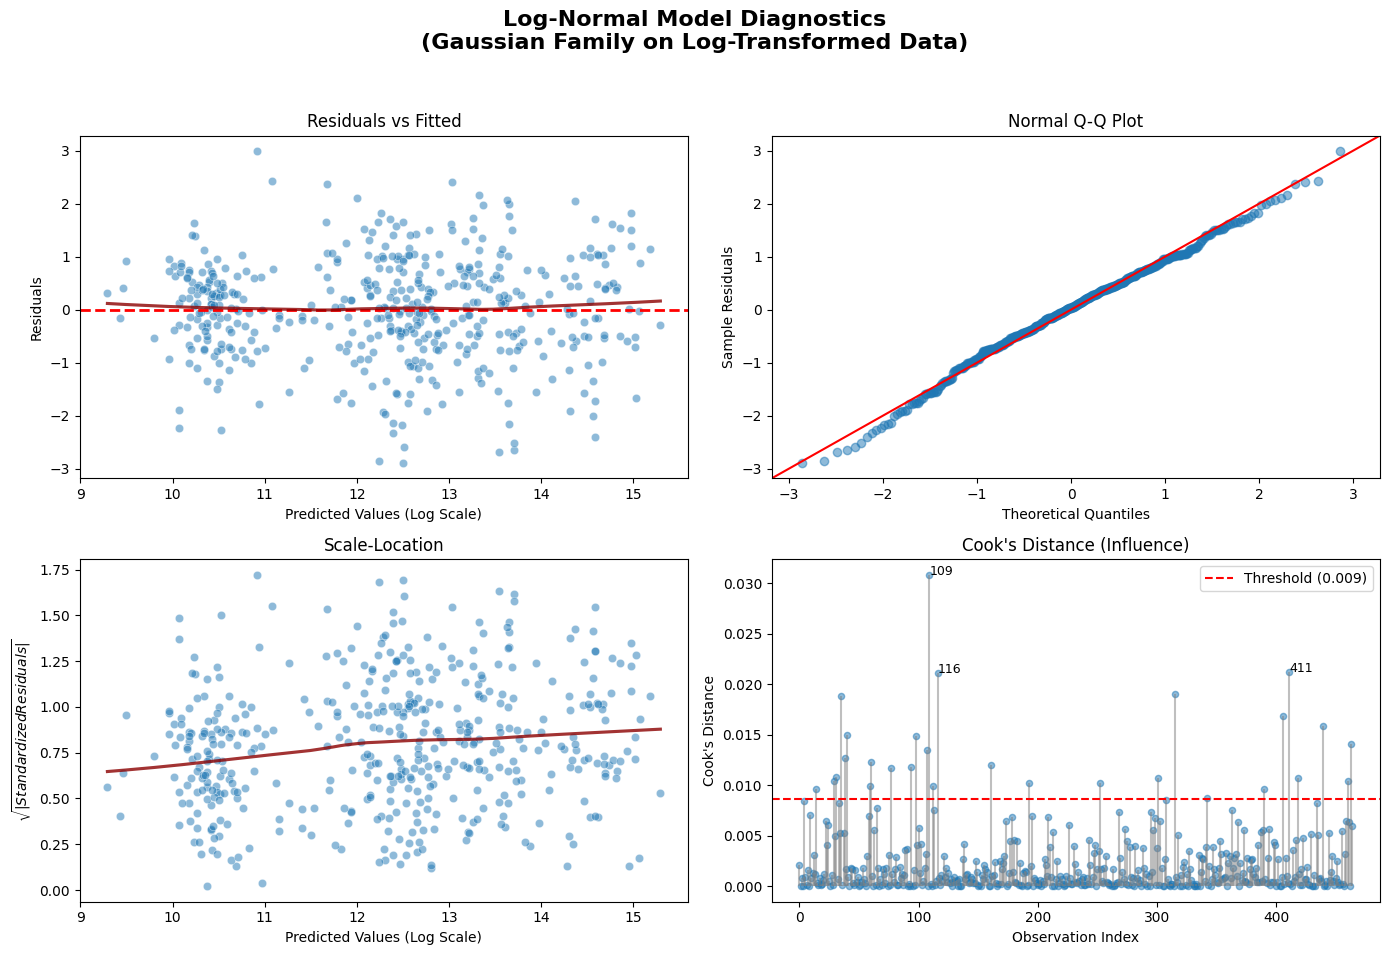

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.gofplots import ProbPlot

def plot_lognormal_diagnostics(result_model):
    """
    Diagnostic panel for Log-Normal GLM.
    Since we modeled Log(Y), residuals should be Normally Distributed.
    """
    # 1. Extract Metrics
    fitted_vals = result_model.mu  # Predicted Log(Amount)
    resid = result_model.resid_deviance # Residuals (Observed - Predicted)
    resid_std = result_model.resid_pearson / np.sqrt(result_model.scale) # Standardized
    
    # 2. Setup Plot Grid
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Log-Normal Model Diagnostics\n(Gaussian Family on Log-Transformed Data)', fontsize=16, fontweight='bold')

    # --- Plot A: Residuals vs Fitted (Linearity Check) ---
    # Look for: Random scatter around 0. No curvature.
    sns.scatterplot(x=fitted_vals, y=resid, ax=axes[0, 0], alpha=0.5, color='#1f77b4')
    axes[0, 0].axhline(0, color='r', linestyle='--', lw=2)
    
    # Add Loess smooth line to check for non-linear patterns
    try:
        sns.regplot(x=fitted_vals, y=resid, scatter=False, ax=axes[0, 0], 
                    lowess=True, line_kws={'color': 'darkred', 'alpha': 0.8})
    except: pass # Skip if lowess fails
    
    axes[0, 0].set_title('Residuals vs Fitted')
    axes[0, 0].set_xlabel('Predicted Values (Log Scale)')
    axes[0, 0].set_ylabel('Residuals')

    # --- Plot B: Q-Q Plot (Normality Check) ---
    # Look for: Points hugging the red line. This is the MOST important plot now.
    QQ = ProbPlot(resid)
    QQ.qqplot(line='45', alpha=0.5, color='#1f77b4', ax=axes[0, 1])
    axes[0, 1].set_title('Normal Q-Q Plot')
    axes[0, 1].set_xlabel('Theoretical Quantiles')
    axes[0, 1].set_ylabel('Sample Residuals')

    # --- Plot C: Scale-Location (Homoscedasticity) ---
    # Look for: Flat trend line. If it slopes up, variance still increases with size.
    sqrt_abs_resid = np.sqrt(np.abs(resid_std))
    sns.scatterplot(x=fitted_vals, y=sqrt_abs_resid, ax=axes[1, 0], alpha=0.5)
    
    try:
        sns.regplot(x=fitted_vals, y=sqrt_abs_resid, scatter=False, ax=axes[1, 0], 
                    lowess=True, line_kws={'color': 'darkred', 'alpha': 0.8})
    except: pass

    axes[1, 0].set_title('Scale-Location')
    axes[1, 0].set_xlabel('Predicted Values (Log Scale)')
    axes[1, 0].set_ylabel('$\sqrt{|Standardized Residuals|}$')

    # --- Plot D: Cook's Distance (Influential Outliers) ---
    # Look for: Spikes above the red line (Threshold = 4/N)
    influence = result_model.get_influence()
    cooks_d = influence.cooks_distance[0]
    n = len(fitted_vals)
    threshold = 4/n
    
    axes[1, 1].vlines(x=np.arange(n), ymin=0, ymax=cooks_d, color='gray', alpha=0.5)
    axes[1, 1].scatter(np.arange(n), cooks_d, alpha=0.5, s=20)
    axes[1, 1].axhline(threshold, color='r', linestyle='--', label=f'Threshold ({threshold:.3f})')
    
    # Label top 3 outliers
    top_idx = np.argsort(cooks_d)[-3:]
    for i in top_idx:
        if cooks_d[i] > threshold:
            axes[1, 1].text(i, cooks_d[i], f'{i}', color='black', fontsize=9)
            
    axes[1, 1].set_title("Cook's Distance (Influence)")
    axes[1, 1].set_xlabel('Observation Index')
    axes[1, 1].set_ylabel("Cook's Distance")
    axes[1, 1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Execute using the result from the previous step (result_ln)
plot_lognormal_diagnostics(result_ln)

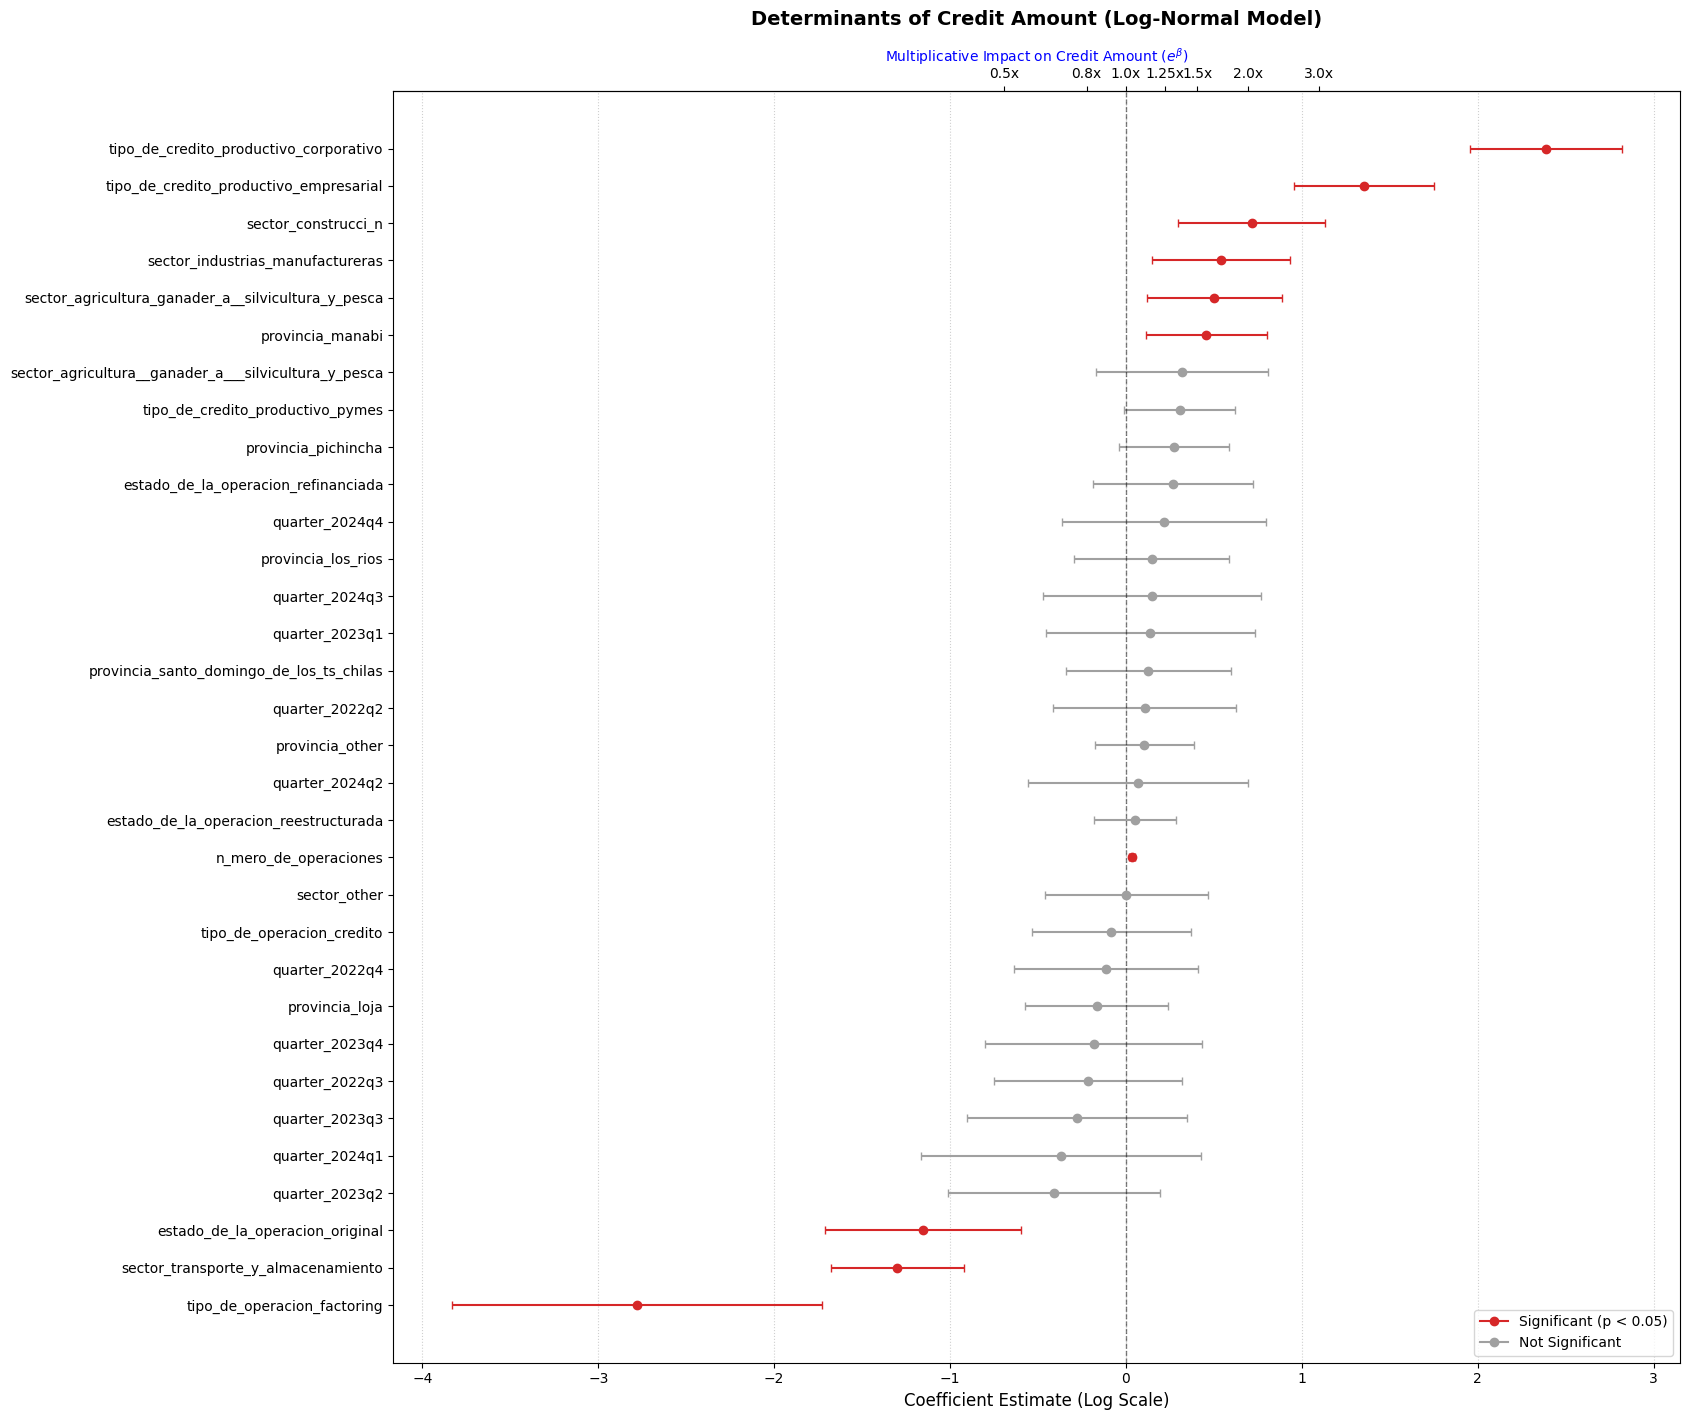

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

def plot_coefficients_colored(result_model):
    """
    Generates a Springer-quality Forest Plot.
    Highlights statistically significant variables (p < 0.05) in Red.
    """
    # 1. Extract Data from Model Result
    # We get coefficients, confidence intervals, and p-values
    df_plot = pd.DataFrame({
        'coef': result_model.params,
        'lower': result_model.conf_int()[0],
        'upper': result_model.conf_int()[1],
        'pvalue': result_model.pvalues
    })
    
    # Calculate error bar lengths for plotting
    df_plot['error_lower'] = df_plot['coef'] - df_plot['lower']
    df_plot['error_upper'] = df_plot['upper'] - df_plot['coef']
    
    # 2. Filter & Sort
    # Remove Intercept (distorts scale)
    df_plot = df_plot.drop(['Intercept'], errors='ignore')
    # Sort by coefficient magnitude for a clean "waterfall" look
    df_plot = df_plot.sort_values('coef')
    
    # 3. Define Colors based on Significance
    # Red for Significant (p < 0.05), Gray for Insignificant
    df_plot['color'] = np.where(df_plot['pvalue'] < 0.05, '#D62728', '#A0A0A0') 
    
    # 4. Plotting
    # Dynamic height based on number of variables
    fig, ax = plt.subplots(figsize=(17, len(df_plot) * 0.4 + 1.5))
    
    # Iterate to plot each variable with its specific color
    for i, (idx, row) in enumerate(df_plot.iterrows()):
        ax.errorbar(row['coef'], i, 
                    xerr=[[row['error_lower']], [row['error_upper']]], 
                    fmt='o', 
                    color=row['color'],      # Dot color
                    ecolor=row['color'],     # Line color
                    capsize=3, elinewidth=1.5, markersize=6)
        
    # 5. Formatting
    # Set Y-axis labels (Variable Names)
    ax.set_yticks(range(len(df_plot)))
    ax.set_yticklabels(df_plot.index, fontsize=10)
    
    # Reference Line at 0 (No Effect)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    # Titles and Labels
    ax.set_title('Determinants of Credit Amount (Log-Normal Model)', fontsize=14, pad=15, fontweight='bold')
    ax.set_xlabel('Coefficient Estimate (Log Scale)', fontsize=12)
    ax.grid(axis='x', linestyle=':', alpha=0.6)
    
    # 6. Custom Legend
    legend_elements = [
        Line2D([0], [0], color='#D62728', marker='o', linestyle='-', label='Significant (p < 0.05)'),
        Line2D([0], [0], color='#A0A0A0', marker='o', linestyle='-', label='Not Significant')
    ]
    ax.legend(handles=legend_elements, loc='lower right')

    # 7. Add "Multiplicative Impact" Axis (Top)
    # This helps readers understand the real-world magnitude (e.g., 2x, 0.5x)
    ax_top = ax.secondary_xaxis('top')
    ticks = np.array([0.5, 0.8, 1.0, 1.25, 1.5, 2.0, 3.0])
    # Only show ticks that fit within the current plot range
    xlim = ax.get_xlim()
    valid_ticks = [t for t in ticks if np.log(t) > xlim[0] and np.log(t) < xlim[1]]
    
    if valid_ticks:
        ax_top.set_xticks(np.log(valid_ticks))
        ax_top.set_xticklabels([f"{t}x" for t in valid_ticks])
        ax_top.set_xlabel('Multiplicative Impact on Credit Amount ($e^{\\beta}$)', fontsize=10, color='blue')

    plt.tight_layout()
    # Save for Springer (High Res)
    plt.savefig('forest_plot_colored.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- EXECUTION ---

plot_coefficients_colored(result_ln)

In [6]:

# 1. Extract the Residuals (Deviance residuals are standard for GLMs)
residuals = result_ln.resid_deviance

# 2. Standardize them (KS Test compares against a Standard Normal N(0,1))
# We subtract the mean (should be close to 0) and divide by the standard deviation
resid_std = (residuals - residuals.mean()) / residuals.std()

# 3. Perform Kolmogorov-Smirnov Test
# Null Hypothesis (H0): The residuals follow a Standard Normal Distribution.
ks_statistic, p_value = stats.kstest(resid_std, 'norm')

print(f"--- Kolmogorov-Smirnov Test for Normality ---")
print(f"KS Statistic: {ks_statistic:.4f}")
print(f"P-Value:      {p_value:.4f}")

# 4. Interpretation Logic for the Paper
alpha = 0.05
if p_value > alpha:
    print("\n RESULT: We FAIL TO REJECT the Null Hypothesis.")
    print("Interpretation: The residuals follow a Gaussian distribution.")
    print("Conclusion: The Log-Normal model specification is statistically valid.")
else:
    print("\n RESULT: We REJECT the Null Hypothesis.")
    print("Interpretation: The residuals deviate from a perfect Gaussian distribution.")
    print("Note: With N=520, this test is extremely sensitive. Rely on the Q-Q plot.")

--- Kolmogorov-Smirnov Test for Normality ---
KS Statistic: 0.0345
P-Value:      0.6245

 RESULT: We FAIL TO REJECT the Null Hypothesis.
Interpretation: The residuals follow a Gaussian distribution.
Conclusion: The Log-Normal model specification is statistically valid.


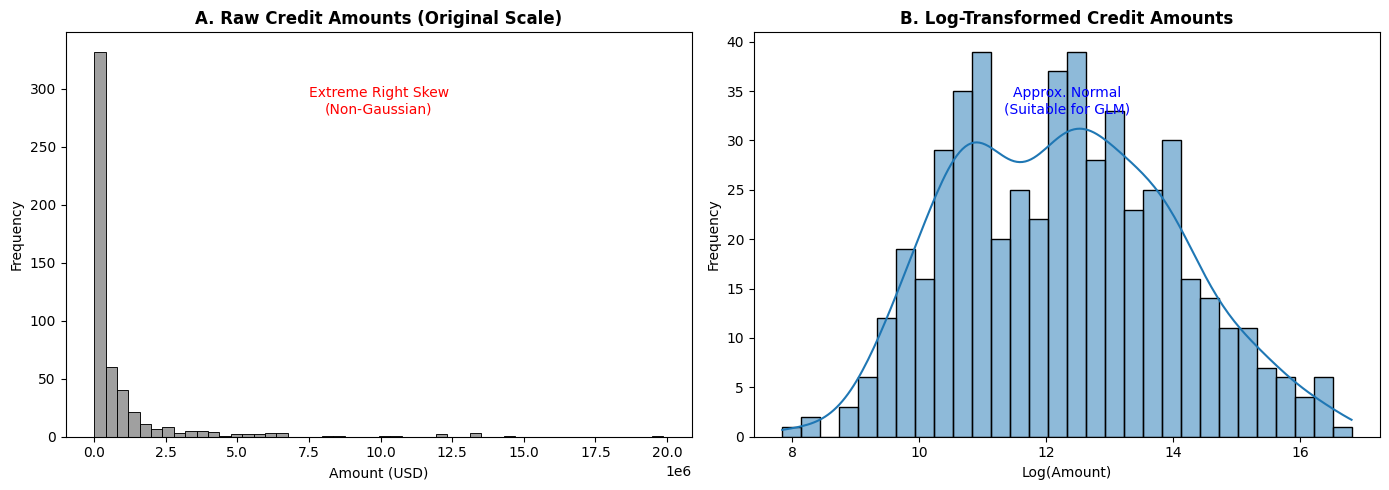

In [7]:

# Load data (assuming df_clean is available from previous steps)
# If not, rely on the previous loading logic
filename = 'cfn_volumencreditocontingente_2025_enero-septiembre.csv'
df_eda = pd.read_csv(filename, sep=';', encoding='latin-1')
df_eda = df_eda[df_eda['SECTOR'] != 'ACTIVIDADES FINANCIERAS Y DE SEGUROS'].copy()
df_eda['monto_otorgado'] = pd.to_numeric(df_eda['MONTO OTORGADO'], errors='coerce')
df_eda = df_eda.dropna(subset=['monto_otorgado'])
df_eda = df_eda[df_eda['monto_otorgado'] > 0]

def plot_distribution_justification(df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Raw Data (The Problem)
    sns.histplot(df['monto_otorgado'], bins=50, kde=False, color='gray', ax=axes[0])
    axes[0].set_title('A. Raw Credit Amounts (Original Scale)', fontweight='bold')
    axes[0].set_xlabel('Amount (USD)')
    axes[0].set_ylabel('Frequency')
    # Scientific notation for x-axis
    axes[0].ticklabel_format(style='sci', axis='x', scilimits=(6,6))
    axes[0].text(0.5, 0.8, 'Extreme Right Skew\n(Non-Gaussian)', 
                 transform=axes[0].transAxes, ha='center', color='red')

    # Plot 2: Log-Transformed (The Solution)
    log_data = np.log(df['monto_otorgado'])
    sns.histplot(log_data, bins=30, kde=True, color='#1f77b4', ax=axes[1])
    axes[1].set_title('B. Log-Transformed Credit Amounts', fontweight='bold')
    axes[1].set_xlabel('Log(Amount)')
    axes[1].set_ylabel('Frequency')
    axes[1].text(0.5, 0.8, 'Approx. Normal\n(Suitable for GLM)', 
                 transform=axes[1].transAxes, ha='center', color='blue')

    plt.tight_layout()
    plt.savefig('eda_distribution_check.png', dpi=300)
    plt.show()

plot_distribution_justification(df_eda)

/var/folders/3c/z87p2q816b55gkkf_05bzyhr0000gn/T/ipykernel_6848/2153274255.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='Sector_Short', x='monto_otorgado', order=order,


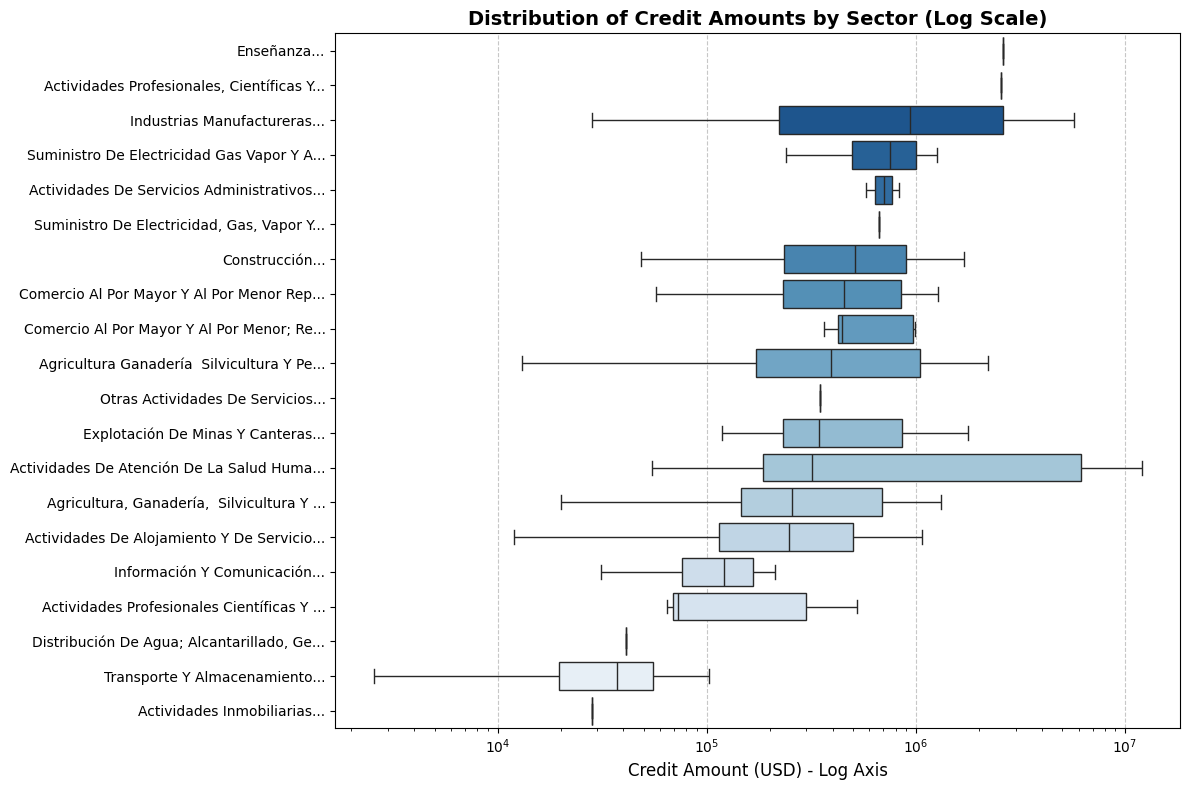

In [8]:
def plot_sector_boxplots(df):
    # Simplify Sector Names for Plotting
    df['Sector_Short'] = df['SECTOR'].str.title().str[:40] + "..."
    
    # Calculate order by Median
    order = df.groupby('Sector_Short')['monto_otorgado'].median().sort_values(ascending=False).index
    
    plt.figure(figsize=(12, 8))
    
    # Log scale on X-axis is often cleaner than logging the data for boxplots
    sns.boxplot(data=df, y='Sector_Short', x='monto_otorgado', order=order, 
                palette='Blues_r', showfliers=False) # Hide extreme outliers for clarity
    
    plt.xscale('log')
    plt.title('Distribution of Credit Amounts by Sector (Log Scale)', fontsize=14, fontweight='bold')
    plt.xlabel('Credit Amount (USD) - Log Axis', fontsize=12)
    plt.ylabel('')
    plt.grid(axis='x', which='major', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig('eda_sector_heterogeneity.png', dpi=300)
    plt.show()

plot_sector_boxplots(df_eda)

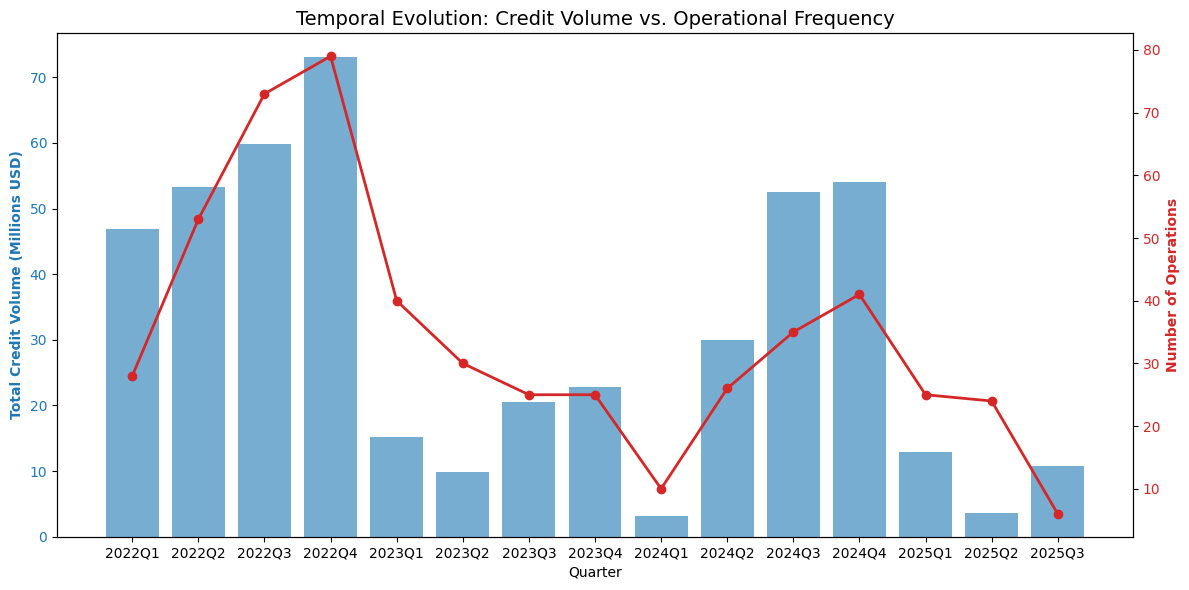

In [10]:
def plot_temporal_dynamics(df):
    # Prep Data
    # 1. Identify the date column
    date_col = [c for c in df.columns if 'FECHA' in c or 'fecha' in c][0]
    
    # 2. Robust Date Parsing (FIXED)
    # We use format='mixed' to handle variations like MM/DD/YYYY vs DD/MM/YYYY automatically
    df['date'] = pd.to_datetime(df[date_col], format='mixed', errors='coerce')
    
    # Drop rows where date conversion failed (if any)
    df = df.dropna(subset=['date']).copy()
    
    df['Quarter'] = df['date'].dt.to_period('Q')
    
    # Aggregate
    agg = df.groupby('Quarter').agg(
        Total_Volume=('monto_otorgado', 'sum'),
        Count=('monto_otorgado', 'count')
    ).reset_index()
    agg['Quarter'] = agg['Quarter'].astype(str)
    
    # Plot
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Bar Plot (Volume)
    color = 'tab:blue'
    ax1.set_xlabel('Quarter')
    ax1.set_ylabel('Total Credit Volume (Millions USD)', color=color, fontweight='bold')
    # Scale to Millions
    ax1.bar(agg['Quarter'], agg['Total_Volume']/1e6, color=color, alpha=0.6, label='Volume')
    ax1.tick_params(axis='y', labelcolor=color)

    # Line Plot (Frequency) on Secondary Axis
    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('Number of Operations', color=color, fontweight='bold')
    ax2.plot(agg['Quarter'], agg['Count'], color=color, marker='o', linewidth=2, label='Operations')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Temporal Evolution: Credit Volume vs. Operational Frequency', fontsize=14)
    fig.tight_layout()
    plt.savefig('eda_temporal_dynamics.png', dpi=300)
    plt.show()

# Run the corrected function
plot_temporal_dynamics(df_eda)